In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parametry układu Lorenza
sigma = 10.0
r = 28.0
b = 8/3

# Przedział czasu [t0, tf]
t_span = (0, 10000)
t_eval = np.linspace(0, 100, 10000)

t_span_1 = (0, 500)
t_eval_1 = np.linspace(0, 100, 10000) # Dużo punktów dla gładkiego wykresu

# Funkcja opisująca układ równań (1)
def lorenz_system(t, state):
    x, y, z = state
    dx = sigma * y - sigma * x
    dy = -x * z + r * x - y
    dz = x * y - b * z
    return [dx, dy, dz]

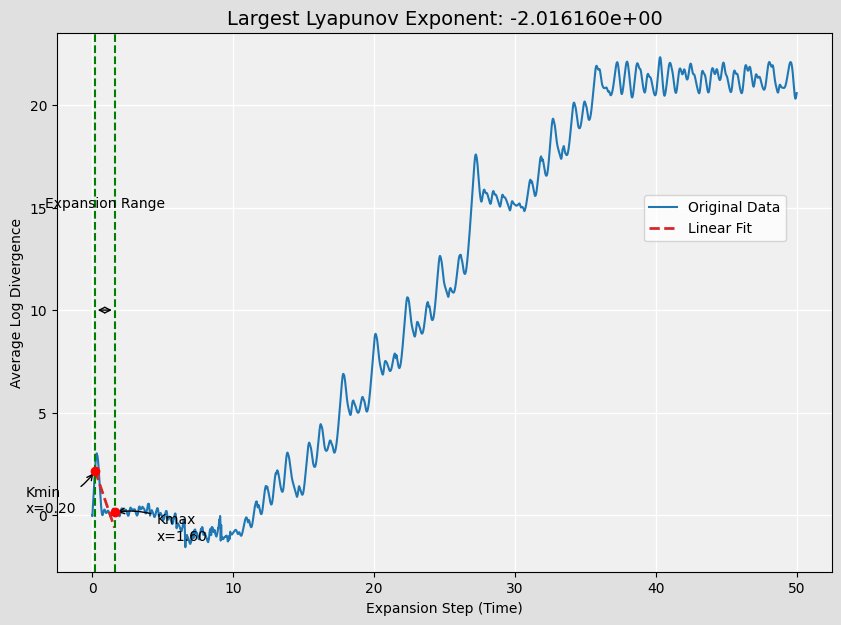

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Parametry układu Lorenza
sigma, r, b = 10.0, 28.0, 8/3.0

def lorenz(t, state):
    x, y, z = state
    return [sigma*(y - x), x*(r - z) - y, x*y - b*z]

# 2. Symulacja dwóch trajektorii bardzo blisko siebie
dt = 0.01
t_max = 50
t_eval = np.arange(0, t_max, dt)

dist_0 = 1e-8  # Początkowa perturbacja (bardzo mała)
state1 = np.array([1.0, 1.0, 1.0])
state2 = state1 + np.array([dist_0, 0, 0])

sol1 = solve_ivp(lorenz, (0, t_max), state1, t_eval=t_eval, method='RK45')
sol2 = solve_ivp(lorenz, (0, t_max), state2, t_eval=t_eval, method='RK45')

# 3. Obliczanie odległości i logarytmu dywergencji
# d(t) = sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
distances = np.linalg.norm(sol1.y - sol2.y, axis=0)
log_divergence = np.log(distances / dist_0)

# 4. Wybór zakresu do dopasowania liniowego (Expansion Range)
# Wybieramy zakres, gdzie wzrost jest liniowy (zanim nastąpi nasycenie)
k_min, k_max = 1000, 2500
x_fit = t_eval[k_min:k_max]
y_fit = log_divergence[k_min:k_max]

# Regresja liniowa (polyfit stopnia 1)
coeffs = np.polyfit(x_fit, y_fit, 1)
lambda_max = coeffs[0]
linear_line = np.polyval(coeffs, x_fit)

# 5. Wykres wzorowany na Twoim obrazku
plt.figure(figsize=(10, 7), facecolor='#e0e0e0')
ax = plt.axes()
ax.set_facecolor('#f0f0f0')

plt.plot(t_eval, log_divergence, label='Original Data', color='#1f77b4', linewidth=1.5)
plt.plot(x_fit, linear_line, '--', color='#d62728', label='Linear Fit', linewidth=2)

# Linie pionowe dla zakresu
plt.axvline(t_eval[k_min], color='green', linestyle='--')
plt.axvline(t_eval[k_max], color='green', linestyle='--')

# Oznaczenia punktów Kmin i Kmax
plt.scatter([t_eval[k_min], t_eval[k_max]], [log_divergence[k_min], log_divergence[k_max]], color='red', zorder=5)

# Adnotacje (strzałki i teksty)
plt.annotate(f'Kmin\nx={t_eval[k_min]:.2f}', xy=(t_eval[k_min], log_divergence[k_min]), xytext=(-50, -30),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))
plt.annotate(f'Kmax\nx={t_eval[k_max]:.2f}', xy=(t_eval[k_max], log_divergence[k_max]), xytext=(30, -20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

# Strzałka Expansion Range
plt.annotate('', xy=(t_eval[k_min], 10), xytext=(t_eval[k_max], 10),
             arrowprops=dict(arrowstyle='<->', color='black'))
plt.text((t_eval[k_min]+t_eval[k_max])/2, 15, 'Expansion Range', ha='center')

plt.title(f"Largest Lyapunov Exponent: {lambda_max:.6e}", fontsize=14)
plt.xlabel("Expansion Step (Time)")
plt.ylabel("Average Log Divergence")
plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.6))
plt.grid(True, which='both', color='white', linestyle='-', linewidth=1)
plt.show()

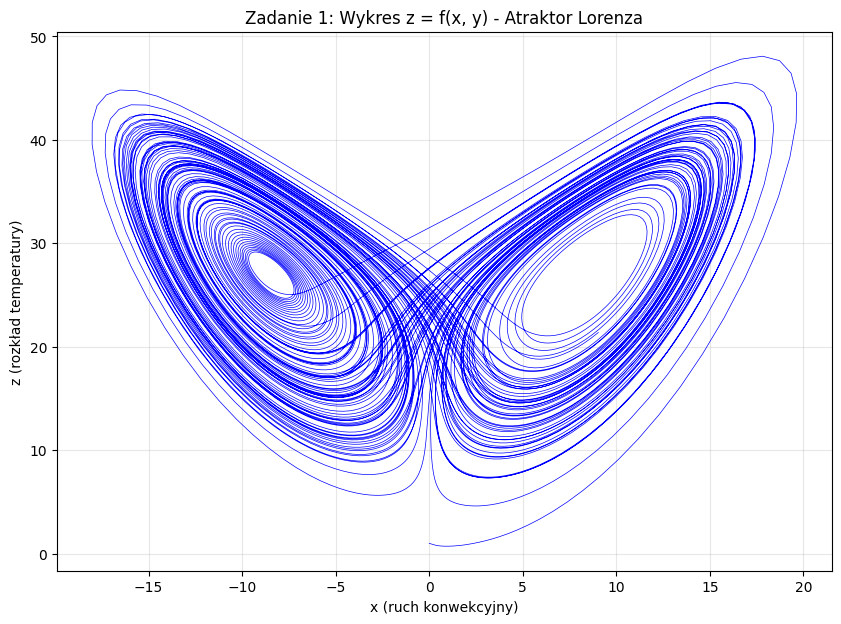

In [2]:
# Warunki początkowe
init_state = [0, 0.5, 1]

# Rozwiązanie (odpowiednik ode45 to metoda 'RK45')
sol = solve_ivp(lorenz_system, t_span, init_state, t_eval=t_eval, method='RK45')

# Wykres z = f(x, y)
plt.figure(figsize=(10, 7))
plt.plot(sol.y[0], sol.y[2], color='blue', linewidth=0.5)
plt.title("Zadanie 1: Wykres z = f(x, y) - Atraktor Lorenza")
plt.xlabel("x (ruch konwekcyjny)")
plt.ylabel("z (rozkład temperatury)")
plt.grid(True, alpha=0.3)
plt.show()

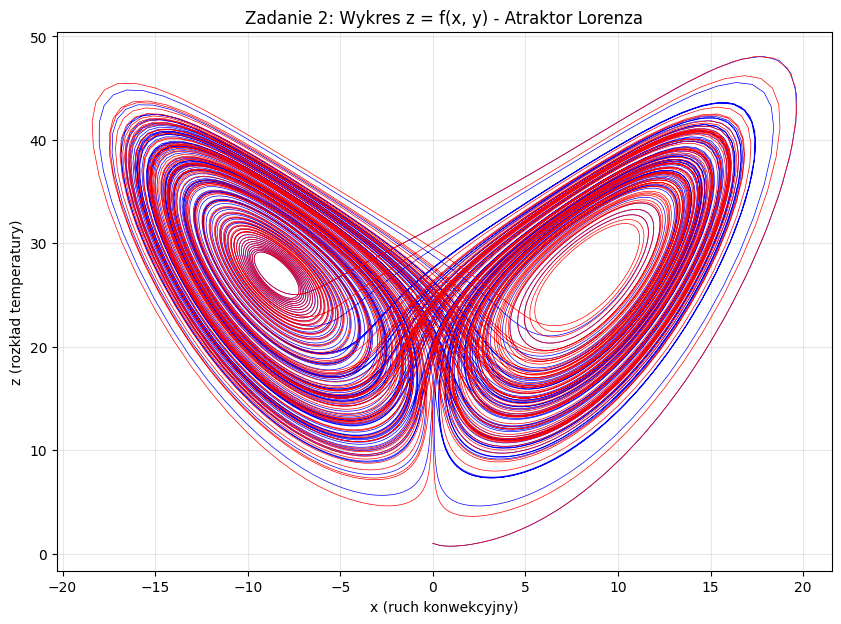

In [16]:
# Warunki początkowe
init_state = [0, 0.5, 1]
init_state_1 = [0.0001, 0.5200, 1]
# Rozwiązanie (odpowiednik ode45 to metoda 'RK45')
sol = solve_ivp(lorenz_system, t_span, init_state, t_eval=t_eval, method='RK45')
sol_1 = solve_ivp(lorenz_system, t_span_1, init_state_1, t_eval=t_eval_1, method='RK45')

# Wykres z = f(x, y)
plt.figure(figsize=(10, 7))
plt.plot(sol.y[0], sol.y[2], color='blue', linewidth=0.5)
plt.plot(sol_1.y[0], sol_1.y[2], color='red', linewidth=0.5)
plt.title("Zadanie 2: Wykres z = f(x, y) - Atraktor Lorenza")
plt.xlabel("x (ruch konwekcyjny)")
plt.ylabel("z (rozkład temperatury)")
plt.grid(True, alpha=0.3)
plt.show()


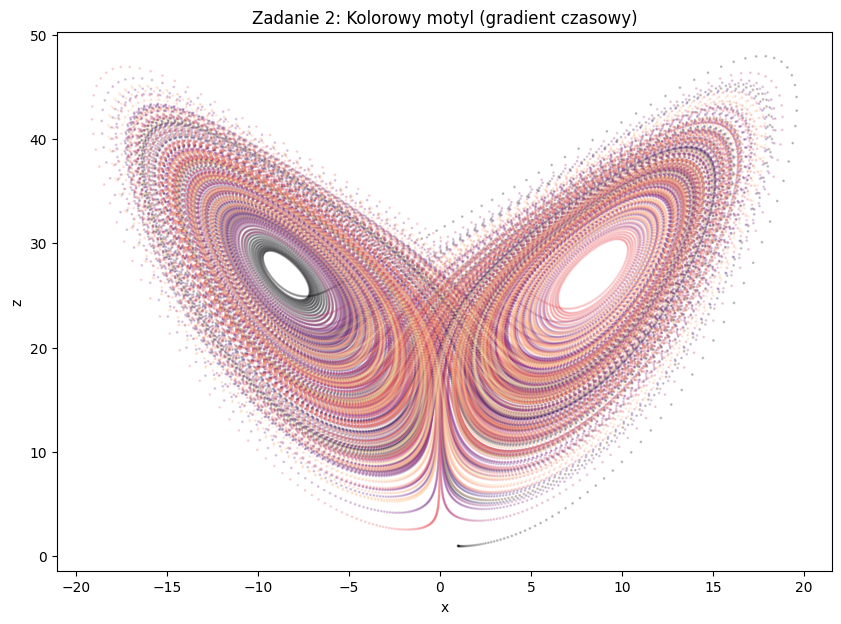

In [ ]:
# Zmieniamy warunki początkowe i zakres czasu dla lepszego efektu wizualnego
new_init = [1, 1, 1]
#t_eval_long = np.linspace(0, 50, 20000)
t_eval_long = np.linspace(0, 500, 100000) #te wartości zagęszczaja nasz obrazek

sol_2 = solve_ivp(lorenz_system, (0, 500), new_init, t_eval=t_eval_long)

plt.figure(figsize=(10, 7))
# Kolorowanie za pomocą gradientu czasowego (scatter z cmap)
plt.scatter(sol_2.y[0], sol_2.y[2], c=sol_2.t, cmap='magma', s=1, alpha=0.2)
#plt.scatter(sol_2.y[0], sol_2.y[2], c=sol_2.t, colo, s=1, alpha=0.2)
plt.title("Zadanie 2: Kolorowy motyl (gradient czasowy)")
plt.xlabel("x")
plt.ylabel("z")
plt.show()

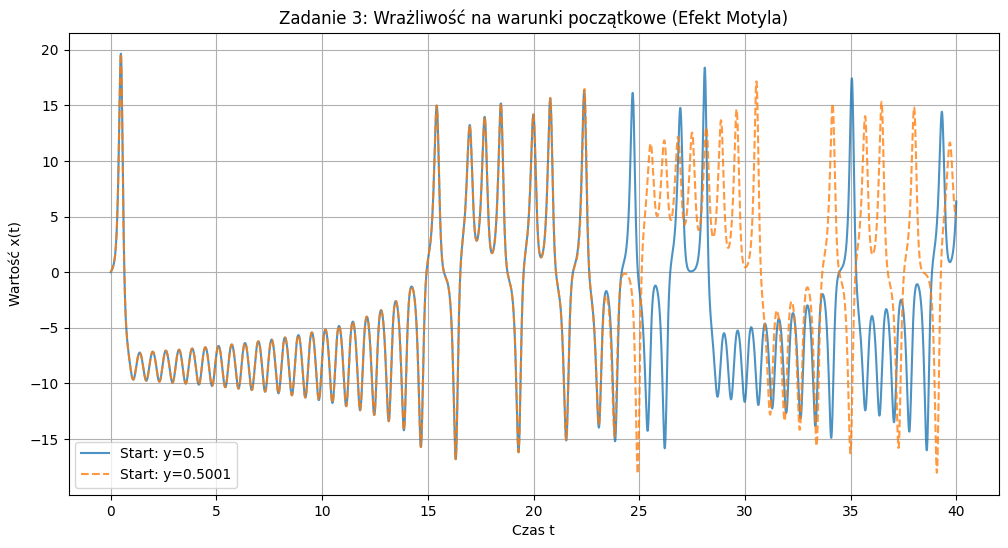

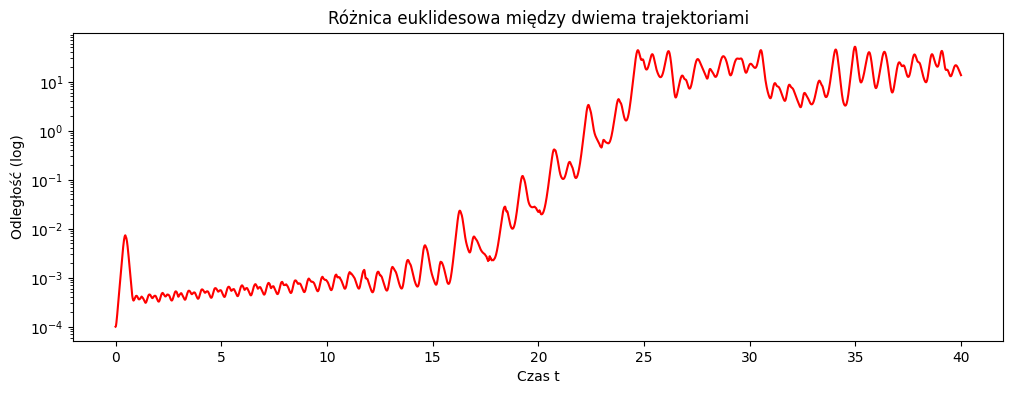

In [4]:
# Dwa bardzo bliskie warunki początkowe
state1 = [0, 0.5, 1]
state2 = [0, 0.5001, 1] # Minimalna różnica w y0

sol3_1 = solve_ivp(lorenz_system, (0, 40), state1, t_eval=np.linspace(0, 40, 4000))
sol3_2 = solve_ivp(lorenz_system, (0, 40), state2, t_eval=np.linspace(0, 40, 4000))

# Porównanie wykresów czasowych x(t)
plt.figure(figsize=(12, 6))
plt.plot(sol3_1.t, sol3_1.y[0], label="Start: y=0.5", alpha=0.8)
plt.plot(sol3_2.t, sol3_2.y[0], label="Start: y=0.5001", linestyle="--", alpha=0.8)

plt.title("Zadanie 3: Wrażliwość na warunki początkowe (Efekt Motyla)")
plt.xlabel("Czas t")
plt.ylabel("Wartość x(t)")
plt.legend()
plt.grid(True)
plt.show()

# Obliczenie różnicy (odległości) między trajektoriami
diff = np.sqrt((sol3_1.y[0]-sol3_2.y[0])**2 + (sol3_1.y[1]-sol3_2.y[1])**2 + (sol3_1.y[2]-sol3_2.y[2])**2)

plt.figure(figsize=(12, 4))
plt.plot(sol3_1.t, diff, color='red')
plt.yscale('log') # Skala logarytmiczna, bo różnica rośnie wykładniczo
plt.title("Różnica euklidesowa między dwiema trajektoriami")
plt.xlabel("Czas t")
plt.ylabel("Odległość (log)")
plt.show()

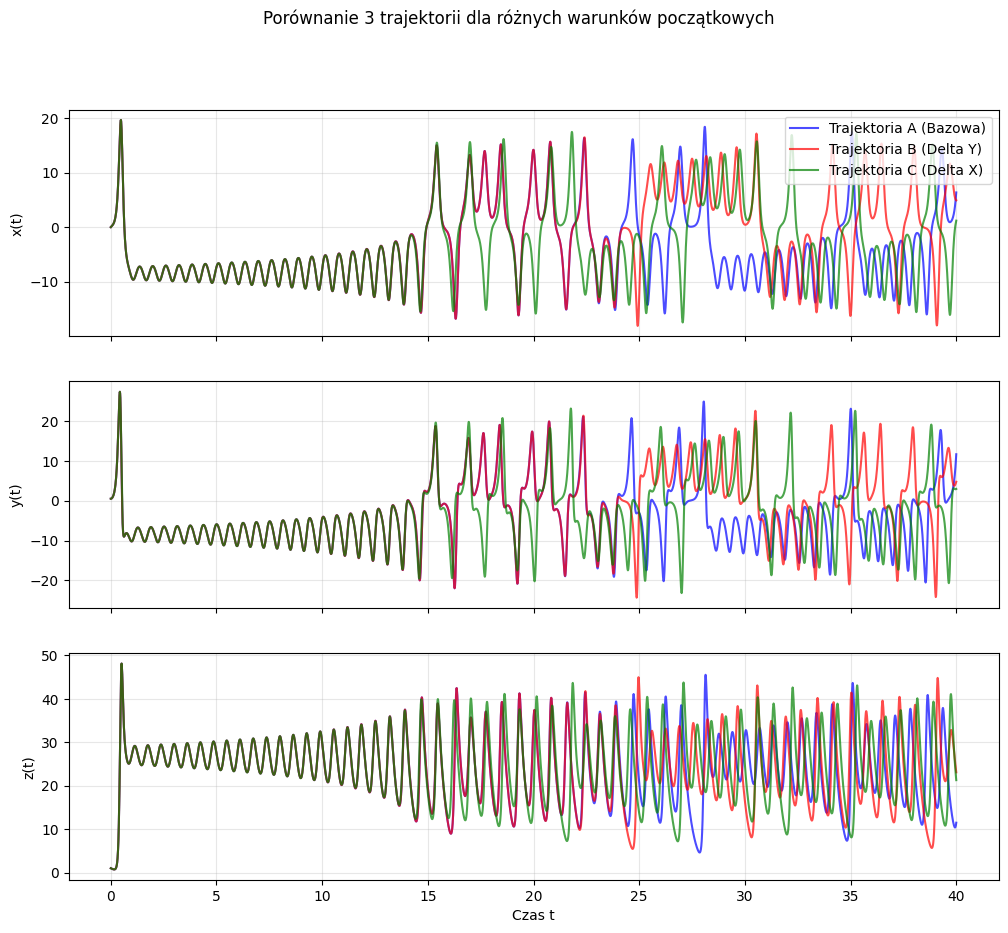

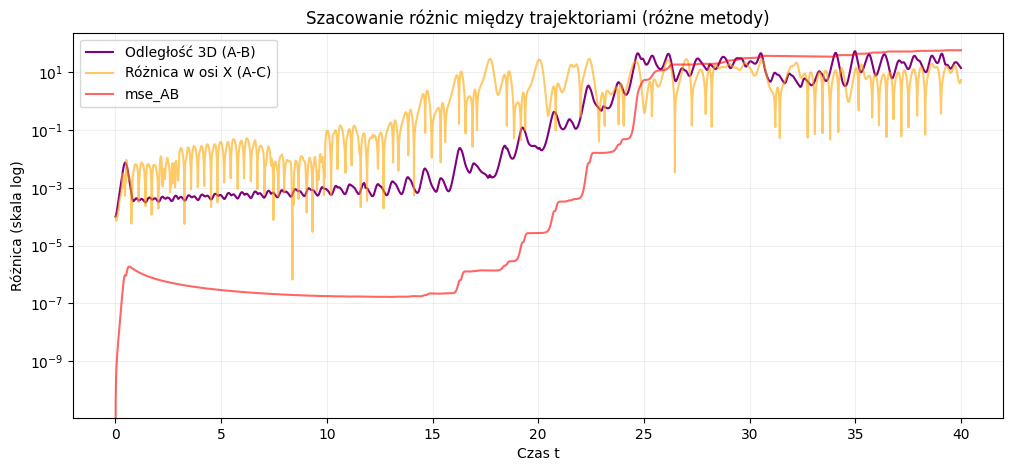

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definicja 3 różnych warunków początkowych (minimalne różnice)
ic1 = [0, 0.5, 1]
ic2 = [0, 0.5001, 1]    # Różnica o 0.0001 w y
ic3 = [0.0001, 0.5, 1]  # Różnica o 0.0001 w x

conditions = [ic1, ic2, ic3]
labels = ['Trajektoria A (Bazowa)', 'Trajektoria B (Delta Y)', 'Trajektoria C (Delta X)']
colors = ['blue', 'red', 'green']
t_eval = np.linspace(0, 40, 4000)

# 1. Obliczanie 3 trajektorii
solutions = []
for ic in conditions:
    sol = solve_ivp(lorenz_system, (0, 40), ic, t_eval=t_eval)
    solutions.append(sol)

# 2. Wykresy czasowe x(t), y(t), z(t) - punkt i. oraz ii.
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
vars_names = ['x(t)', 'y(t)', 'z(t)']

for i in range(3): # dla x, y, z
    for j in range(3): # dla każdej trajektorii
        axes[i].plot(t_eval, solutions[j].y[i], label=labels[j], color=colors[j], alpha=0.7)
    axes[i].set_ylabel(vars_names[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0: axes[i].legend(loc='upper right')

plt.xlabel("Czas t")
plt.suptitle("Porównanie 3 trajektorii dla różnych warunków początkowych")
plt.show()

# 3. Szacowanie różnic - punkt iii. (Różne metody)
# Metoda A: Odległość Euklidesowa w przestrzeni 3D (A vs B)
dist_AB = np.sqrt(np.sum((solutions[0].y - solutions[1].y)**2, axis=0))

# Metoda B: Różnica bezwzględna w osi X (A vs C)
diff_X_AC = np.abs(solutions[0].y[0] - solutions[2].y[0])

# Metoda C: Błąd Średniokwadratowy (MSE) kroczący - pokazuje skumulowaną różnicę
mse_AB = np.cumsum((solutions[0].y[0] - solutions[1].y[0])**2) / (np.arange(len(t_eval)) + 1)

# Wykres porównawczy metod
plt.figure(figsize=(12, 5))
plt.plot(t_eval, dist_AB, label="Odległość 3D (A-B)", color='purple')
plt.plot(t_eval, diff_X_AC, label="Różnica w osi X (A-C)", color='orange', alpha=0.6)
plt.plot(t_eval, mse_AB, label="mse_AB", color='red', alpha=0.6)
plt.yscale('log') # Skala logarytmiczna najlepiej pokazuje tempo rozbieżności
plt.title("Szacowanie różnic między trajektoriami (różne metody)")
plt.ylabel("Różnica (skala log)")
plt.xlabel("Czas t")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()